In [4]:
import pandas as pd 
import numpy as np
import os
import matplotlib.pyplot as plt

import sys
sys.path.append('/home/spankaew/Git/Git_Curie/AstroLogics/')

In [6]:
# Load Endpoint ARI scores
endpoint = pd.read_csv('/home/spankaew/Git/Git_Curie/AstroLogics/data/rand_experiment/rand_index_endpointclustering_v3.csv', index_col=0)
endpoint.fillna(0, inplace=True)
endpoint = endpoint.max(axis = 0)

# Load All-trajectory ARI scores
alltraj = pd.read_csv('/home/spankaew/Git/Git_Curie/AstroLogics/data/rand_experiment/rand_index_alltrajclustering_v3.csv', index_col=0)
alltraj.fillna(0, inplace=True)
alltraj = alltraj.max(axis = 0)

# Load All-trajectory Euclidean ARI scores
alltraj_euclidean = pd.read_csv('/home/spankaew/Git/Git_Curie/AstroLogics/data/rand_experiment/rand_index_alltrajclustering_euclidean.csv', index_col=0)
alltraj_euclidean.fillna(0, inplace=True)
alltraj_euclidean = alltraj_euclidean.max(axis = 0)

# Combine both scores into a new DataFrame
new_ari_score = pd.concat([endpoint, alltraj, alltraj_euclidean], axis=1, keys=['Max_ARI_endpoint', 'Max_ARI_alltraj', 'Max_ARI_alltraj_euclidean'])

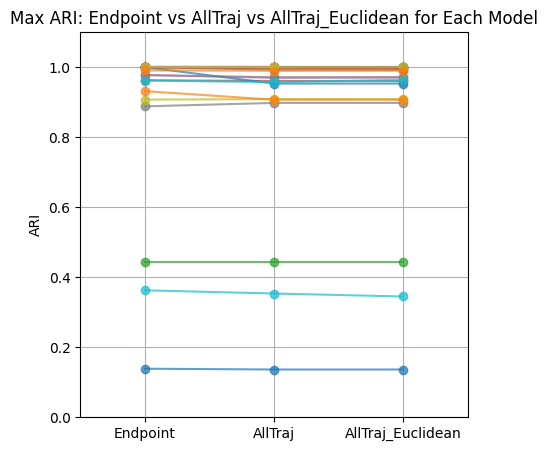

In [7]:
plt.figure(figsize=(5, 5))
for idx, row in new_ari_score.iterrows():
    plt.plot([0, 1, 2], [row['Max_ARI_endpoint'], row['Max_ARI_alltraj'], row['Max_ARI_alltraj_euclidean']], marker='o', label=idx, alpha = 0.7)
plt.ylabel('ARI')
plt.ylim(0, 1.1)
plt.xticks([0, 1, 2], ['Endpoint', 'AllTraj', 'AllTraj_Euclidean'])
plt.xlim(-0.5, 2.5)
plt.title('Max ARI: Endpoint vs AllTraj vs AllTraj_Euclidean for Each Model')
plt.grid(True)
plt.show()


In [9]:
model_attributes = pd.read_csv('/home/spankaew/Git/Git_Curie/AstroLogics/data/attractor_group/attractor_counts.csv', index_col=0)
model_attributes.set_index('project_name', inplace=True)
model_attributes.drop(index = ['toy_reprogramming_1','herault_hematopoiesis'], inplace=True)
model_attributes = pd.concat([model_attributes, new_ari_score], axis=1, ignore_index = False)
model_attributes.sort_values(by='Max_ARI_endpoint', ascending=False, inplace=True)
model_attributes

,num_model,num_attractors,gini_score,Max_ARI_endpoint,Max_ARI_alltraj,Max_ARI_alltraj_euclidean
Toll Pathway of Drosophila Signaling Pathway_23868318,16,6,0.166667,1.000000,1.000000,1.000000
HH Pathway of Drosophila Signaling Pathways_23868318,1000,1000,0.000000,1.000000,1.000000,1.000000
VEGF Pathway of Drosophila Signaling Pathway_23868318,1000,390,0.247405,1.000000,0.999516,0.999516
FGF pathway of Drosophila Signaling Pathways_23868318,1000,570,0.250484,1.000000,0.998361,0.996717
toy_reprogramming,8,8,0.000000,1.000000,1.000000,NaN
test_bonesis,88,2,0.090909,1.000000,1.000000,NaN
Processing of Spz Network from the Drosophila Signaling Pathway_23868318,1000,152,0.398947,1.000000,0.999890,0.999779
Body Segmentation in Drosophila 2013_23520449,1000,86,0.549326,1.000000,0.953078,0.953078
Mammalian Cell Cycle_19118495,1000,7,0.642571,1.000000,0.992837,0.992837
Death Receptor Signaling_20221256,1000,16,0.285500,1.000000,1.000000,1.000000
